# Exploring The Sintel Dataset

This notebook collects the Sintel diagnostics used in the paper: the directionality comparison and raw-frame visualizations. 

## Quick and publication-scale runs

The `paper` profile uses the saved 250,000-patch HC20 artifact and compares $X(1500,30)$, $X(1500,50)$ and $X(50,60)$ exactly as in the manuscript. The `quick` profile uses the smaller saved artifact and shows $X(300,50)$. Change `profile` below (or set `OPTICAL_FLOW_PROFILE`) to switch between them.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import circle_bundles as cb

ROOT = Path.cwd().resolve()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent

profile = Path(os.environ.get("OPTICAL_FLOW_PROFILE", "paper")).stem

if profile == "quick":
    artifact_name = "preprocessed_quick.v1.npz"
    filts = [(300, 0.5)]
elif profile == "paper":
    artifact_name = "HC20_Flow_Patches.v1.npz"
    filts = [(1500, 0.3), (1500, 0.5), (50, 0.6)]
else:
    raise ValueError("profile must be either 'quick' or 'paper'")

figure_dir = ROOT / "results" / profile / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
print(f"Running the {profile} profile.")

Running the paper profile.


# Load The High-Contrast Sample

Open the saved high-contrast sample. The paper artifact contains the 250,000 patches obtained after retaining the top 20 percent by contrast norm and downsampling.

In [2]:
artifact_path = Path(
    os.environ.get("OPTICAL_FLOW_PREPROCESSED", ROOT / "data" / artifact_name)
).expanduser()

if not artifact_path.is_file():
    raise RuntimeError(f"Preprocessed artifact not found: {artifact_path}")

with np.load(artifact_path, allow_pickle=False) as archive:
    metadata = json.loads(str(archive["metadata_json"].item()))
    columns = {
        name: np.asarray(archive[metadata["key_map"][name]])
        for name in metadata["scalar_columns"]
    }
    patches = np.asarray(archive["patches"])

patch_df = pd.DataFrame(columns)
patch_df.insert(0, "patch", list(patches))
print(f"{len(patch_df):,} high-contrast optical flow patches loaded")
print(f"Available density columns: {[c for c in patch_df if c.startswith('density_')]}")

250,000 high-contrast optical flow patches loaded
Available density columns: ['density_10', 'density_50', 'density_100', 'density_200', 'density_300', 'density_1500']


# Predominant Direction And Directionality

Construct each dense-core subset used in the paper, then compute the predominant direction and directionality of every selected patch. The notation $X(k,p)$ denotes the top $100p$ percent by the density estimate $1/\rho_k(x)$.

In [3]:
dir_dict = {}

#The full high-contrast sample X is the fourth curve in the manuscript figure
all_predom_dirs, all_directionality = cb.get_predominant_dirs(patches)
dir_dict["X"] = {
    "data": patches,
    "predom_dirs": all_predom_dirs,
    "directionality": all_directionality,
    "norms": patch_df["norm"].to_numpy(),
    "title": "X",
}

for k, p in filts:
    density_column = f"density_{k}"
    if density_column not in patch_df:
        raise ValueError(f"The selected artifact does not contain {density_column}.")

    ordered = patch_df.sort_values(
        density_column,
        ascending=False,
        kind="mergesort",
    ).reset_index(drop=True)
    n_samples = int(p*len(ordered))
    dataset = np.vstack(ordered["patch"])[:n_samples]

    predom_dirs, directionality = cb.get_predominant_dirs(dataset)
    dir_dict[(k, p)] = {
        "data": dataset,
        "predom_dirs": predom_dirs,
        "directionality": directionality,
        "norms": ordered["norm"].to_numpy()[:n_samples],
        "title": f"X({k},{int(100*p)})",
    }
    print(f"X({k}, {int(100*p)}) contains {n_samples:,} patches")

X(1500, 30) contains 75,000 patches
X(1500, 50) contains 125,000 patches
X(50, 60) contains 150,000 patches


Finally, compare the directionality distributions across the dense-core subsets. This is the computation underlying the manuscript's `Distributions_Of_Directionality` figure.

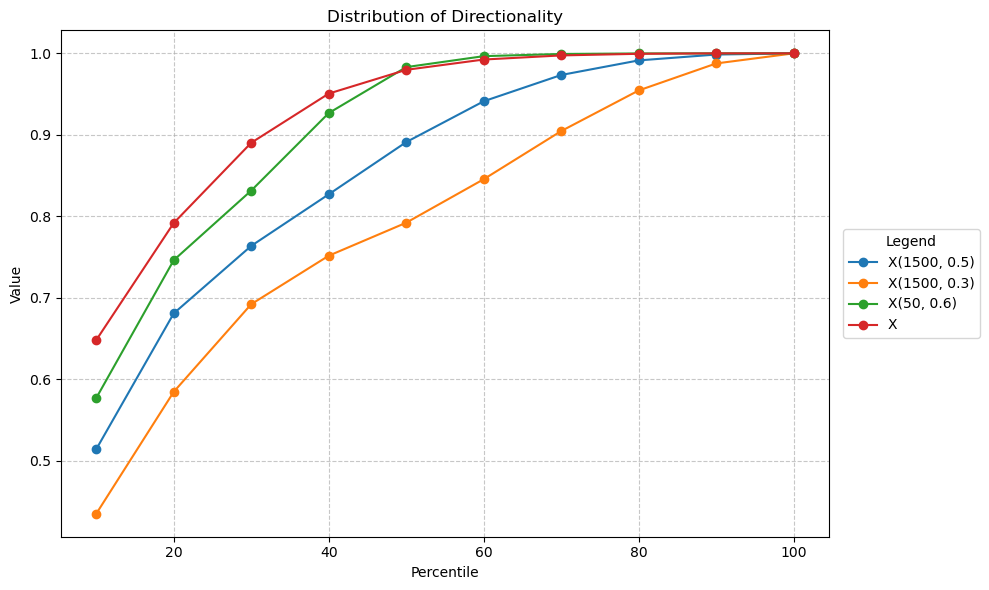

Saved /Users/bradturow/Desktop/optical_flow_paper/results/paper/figures/directionality_distribution.pdf


In [4]:
C = 10    #Step size for percentiles in the manuscript figure
percentiles = np.arange(C, 101, C)

fig, ax = plt.subplots(figsize=(10, 6))
directionality_percentiles = {}

plot_order = (
    [(1500, 0.5), (1500, 0.3), (50, 0.6), "X"]
    if profile == "paper"
    else [(300, 0.5), "X"]
)

for key in plot_order:
    result = dir_dict[key]
    values = np.percentile(result["directionality"], percentiles)
    label = (
        "X" if key == "X"
        else f"X({key[0]}, {key[1]})"
    )
    directionality_percentiles[result["title"]] = values
    ax.plot(percentiles, values, label=label, marker="o")

ax.set(xlabel="Percentile", ylabel="Value",
       title="Distribution of Directionality")
ax.legend(title="Legend", bbox_to_anchor=(1.01, 0.5), loc="center left")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

directionality_path = figure_dir / "directionality_distribution.pdf"
fig.savefig(directionality_path, bbox_inches="tight")
plt.show()
print(f"Saved {directionality_path}")

# Remaining Manuscript Diagnostics

The directionality comparison above is complete. The weak-directionality patch samples, top-one-percent fiber projections and labeled-frame panels still require their exact legacy selections to be identified.

## Superimposing Optical Flow Fields On Image Frames

The original notebook also superimposed flow vectors on Sintel frames. This section requires the raw `MPI-Sintel-complete` directory and is not needed for the directionality computation above. Set `MPI_SINTEL_ROOT` to enable it. The first frame below is a reproducible diagnostic; the exact frames used in the paper will be recorded separately once their old `KEEPER` labels have been matched.

In [8]:
sintel_value = os.environ.get("MPI_SINTEL_ROOT")
sintel_root = Path(sintel_value).expanduser() if sintel_value else None
overlay_path = None

if sintel_root is None or not sintel_root.is_dir():
    print("Raw-frame diagnostic skipped. Set MPI_SINTEL_ROOT to MPI-Sintel-complete to run it.")
else:
    import imageio.v3 as iio
    from circle_bundles.optical_flow.flow_frames import get_sintel_scene_folders

    training_root = sintel_root / "training"
    image_folders = get_sintel_scene_folders(training_root, scene_type="clean")
    flow_folders = get_sintel_scene_folders(training_root, scene_type="flow")

    scene_index = 0
    frame_index = 0
    image_path = sorted(image_folders[scene_index].glob("*.png"))[frame_index]
    flow_path = flow_folders[scene_index] / f"{image_path.stem}.flo"

    image = iio.imread(image_path)
    flow = cb.read_flo(flow_path)
    height, width = flow.shape[:2]
    ys = np.linspace(0, height - 1, 20).astype(int)
    xs = np.linspace(0, width - 1, 30).astype(int)
    grid_y, grid_x = np.meshgrid(ys, xs, indexing="ij")

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(image)
    ax.quiver(
        grid_x, grid_y,
        flow[grid_y, grid_x, 0], -flow[grid_y, grid_x, 1],
        color="red", angles="xy", scale_units="xy", scale=1/1.5, width=0.001,
    )
    ax.axis("off")
    overlay_path = figure_dir / "sintel_flow_overlay_candidate.pdf"
    fig.savefig(overlay_path, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Scene: {image_folders[scene_index].name}; frame: {image_path.name}")

Raw-frame diagnostic skipped. Set MPI_SINTEL_ROOT to MPI-Sintel-complete to run it.


## Reproduction record

Save a small receipt containing the dense-core parameters, directionality percentiles, artifact identity and software versions used for this run.

In [ ]:
import hashlib
import platform
import subprocess
from datetime import datetime, timezone

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024*1024), b""):
            digest.update(block)
    return digest.hexdigest()

def git_value(*args):
    try:
        return subprocess.check_output(
            ["git", *args], cwd=ROOT, text=True, stderr=subprocess.DEVNULL
        ).strip()
    except (OSError, subprocess.CalledProcessError):
        return None

run_record = {
    "experiment": "Sintel data diagnostics",
    "profile": profile,
    "data_source": {
        "filename": artifact_path.name,
        "sha256": file_sha256(artifact_path),
        "preprocessed_patch_count": len(patch_df),
    },
    "dense_cores": {
        result["title"]: {
            "patch_count": len(result["data"]),
            "directionality_percentiles": {
                str(int(percentile)): float(value)
                for percentile, value in zip(
                    percentiles, directionality_percentiles[result["title"]]
                )
            },
        }
        for result in dir_dict.values()
    },
    "outputs": {
        "directionality_figure": str(directionality_path.relative_to(ROOT)),
        "flow_overlay": None if overlay_path is None else str(overlay_path.relative_to(ROOT)),
    },
    "provenance": {
        "notebook": "notebooks/00_sintel_data_diagnostics.ipynb",
        "repository_commit": git_value("rev-parse", "HEAD"),
        "repository_had_uncommitted_changes": bool(git_value("status", "--porcelain")),
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "python_version": platform.python_version(),
        "numpy_version": np.__version__,
        "circle_bundles_version": getattr(cb, "__version__", "unknown"),
    },
}

record_path = ROOT / "results" / profile / "sintel_diagnostics_run.json"
record_path.parent.mkdir(parents=True, exist_ok=True)
record_path.write_text(json.dumps(run_record, indent=2, sort_keys=True) + "\n")
print(f"Wrote reproduction record to {record_path}")
run_record